
# Question and Answer Chat Bots

-----------------------

## Loading the Data

We will be working with the Babi Data Set from Facebook Research.

Full Details: https://research.fb.com/downloads/babi/



In [5]:
import pickle
import numpy as np

In [6]:
with open("train_qa.txt", "rb") as fp:   # Unpickling, read as binary
    train_data =  pickle.load(fp)

In [7]:
with open("test_qa.txt", "rb") as fp:   
    test_data =  pickle.load(fp)

----

## Exploring the Format of the Data

In [10]:
type(test_data)

list

In [11]:
type(train_data)

list

In [12]:
len(test_data)

1000

In [13]:
len(train_data)

10000

In [14]:
train_data[0] #list of tuples

(['Mary',
  'moved',
  'to',
  'the',
  'bathroom',
  '.',
  'Sandra',
  'journeyed',
  'to',
  'the',
  'bedroom',
  '.'],
 ['Is', 'Sandra', 'in', 'the', 'hallway', '?'],
 'no')

In [15]:
' '.join(train_data[0][0])

'Mary moved to the bathroom . Sandra journeyed to the bedroom .'

In [16]:
' '.join(train_data[0][1])

'Is Sandra in the hallway ?'

In [17]:
train_data[0][2]

'no'

-----

## Setting up Vocabulary of All Words

In [19]:
# Create a set that holds the vocab words
vocab = set()

In [20]:
all_data = test_data + train_data

In [21]:
for story, question , answer in all_data:
    # In case you don't know what a union of sets is:
    # https://www.programiz.com/python-programming/methods/set/union
    vocab = vocab.union(set(story))
    vocab = vocab.union(set(question))

In [22]:
vocab.add('no')
vocab.add('yes')

In [23]:
vocab

{'.',
 '?',
 'Daniel',
 'Is',
 'John',
 'Mary',
 'Sandra',
 'apple',
 'back',
 'bathroom',
 'bedroom',
 'discarded',
 'down',
 'dropped',
 'football',
 'garden',
 'got',
 'grabbed',
 'hallway',
 'in',
 'journeyed',
 'kitchen',
 'left',
 'milk',
 'moved',
 'no',
 'office',
 'picked',
 'put',
 'the',
 'there',
 'to',
 'took',
 'travelled',
 'up',
 'went',
 'yes'}

In [24]:
vocab_len = len(vocab) + 1 #we add an extra space to hold a 0 for Keras's pad_sequences

In [25]:
max_story_len = max([len(data[0]) for data in all_data])

In [26]:
max_story_len

156

In [27]:
max_question_len = max([len(data[1]) for data in all_data])

In [28]:
max_question_len

6

## Vectorizing the Data

In [30]:
vocab

{'.',
 '?',
 'Daniel',
 'Is',
 'John',
 'Mary',
 'Sandra',
 'apple',
 'back',
 'bathroom',
 'bedroom',
 'discarded',
 'down',
 'dropped',
 'football',
 'garden',
 'got',
 'grabbed',
 'hallway',
 'in',
 'journeyed',
 'kitchen',
 'left',
 'milk',
 'moved',
 'no',
 'office',
 'picked',
 'put',
 'the',
 'there',
 'to',
 'took',
 'travelled',
 'up',
 'went',
 'yes'}

In [31]:
# Reserve 0 for pad_sequences
vocab_size = len(vocab) + 1
vocab_size

38

In [32]:
%pip install tensorflow
%pip install keras

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


-----------

In [34]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

2026-07-08 22:48:10.941991: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [35]:
# integer encode sequences of words
tokenizer = Tokenizer(filters=[])
tokenizer.fit_on_texts(vocab)

In [36]:
tokenizer.word_index

{'up': 1,
 'went': 2,
 'football': 3,
 'there': 4,
 'bathroom': 5,
 'garden': 6,
 'apple': 7,
 'the': 8,
 'in': 9,
 'grabbed': 10,
 'down': 11,
 'to': 12,
 'hallway': 13,
 'discarded': 14,
 'took': 15,
 'sandra': 16,
 'john': 17,
 'milk': 18,
 'travelled': 19,
 'put': 20,
 'moved': 21,
 'dropped': 22,
 'daniel': 23,
 'mary': 24,
 'journeyed': 25,
 '.': 26,
 'got': 27,
 'kitchen': 28,
 'yes': 29,
 'bedroom': 30,
 'back': 31,
 'picked': 32,
 'no': 33,
 'office': 34,
 'left': 35,
 'is': 36,
 '?': 37}

In [37]:
train_story_text = []
train_question_text = []
train_answers = []

for story,question,answer in train_data:
    train_story_text.append(story)
    train_question_text.append(question)
    train_answers.append(answer)

In [38]:
train_story_seq = tokenizer.texts_to_sequences(train_story_text)

In [39]:
len(train_story_text)

10000

In [40]:
len(train_story_seq)

10000

In [41]:
#word_index = tokenizer.word_index

### Functionalize Vectorization

In [43]:
def vectorize_stories(data, word_index=tokenizer.word_index, max_story_len=max_story_len,max_question_len=max_question_len):
    '''
    INPUT: 
    
    data: consisting of Stories,Queries,and Answers
    word_index: word index dictionary from tokenizer
    max_story_len: the length of the longest story (used for pad_sequences function)
    max_question_len: length of the longest question (used for pad_sequences function)


    OUTPUT:
    
    Vectorizes the stories,questions, and answers into padded sequences. We first loop for every story, query , and
    answer in the data. Then we convert the raw words to an word index value. Then we append each set to their appropriate
    output list. Then once we have converted the words to numbers, we pad the sequences so they are all of equal length.
    
    Returns this in the form of a tuple (X,Xq,Y) (padded based on max lengths)
    '''    
    # X = STORIES
    X = []
    # Xq = QUERY/QUESTION
    Xq = []
    # Y = CORRECT ANSWER
    Y = []
    
    for story, query, answer in data:
        
        # Grab the word index for every word in story
        x = [word_index[word.lower()] for word in story]
        # Grab the word index for every word in query
        xq = [word_index[word.lower()] for word in query]
        
        # Grab the Answers (either Yes/No so we don't need to use list comprehension here)
        # Index 0 is reserved so we're going to use + 1
        y = np.zeros(len(word_index) + 1)
        
        # Now that y is all zeros and we know its just Yes/No , we can use numpy logic to create this assignment
        #
        y[word_index[answer]] = 1
        
        # Append each set of story,query, and answer to their respective holding lists
        X.append(x)
        Xq.append(xq)
        Y.append(y)
        
    # Finally, pad the sequences based on their max length so the RNN can be trained on uniformly long sequences.
        
    # RETURN TUPLE FOR UNPACKING
    return (pad_sequences(X, maxlen=max_story_len),pad_sequences(Xq, maxlen=max_question_len), np.array(Y))

In [44]:
inputs_train, queries_train, answers_train = vectorize_stories(train_data)

In [45]:
inputs_test, queries_test, answers_test = vectorize_stories(test_data)

In [46]:
inputs_test

array([[ 0,  0,  0, ...,  8, 30, 26],
       [ 0,  0,  0, ...,  8,  6, 26],
       [ 0,  0,  0, ...,  8,  6, 26],
       ...,
       [ 0,  0,  0, ...,  8,  7, 26],
       [ 0,  0,  0, ...,  8,  6, 26],
       [ 0,  0,  0, ...,  7,  4, 26]], dtype=int32)

In [47]:
queries_test

array([[36, 17,  9,  8, 28, 37],
       [36, 17,  9,  8, 28, 37],
       [36, 17,  9,  8,  6, 37],
       ...,
       [36, 24,  9,  8, 30, 37],
       [36, 16,  9,  8,  6, 37],
       [36, 24,  9,  8,  6, 37]], dtype=int32)

In [48]:
answers_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [49]:
sum(answers_test)

array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0., 497.,   0.,   0.,   0.,
       503.,   0.,   0.,   0.,   0.])

In [50]:
tokenizer.word_index['yes']

29

In [51]:
tokenizer.word_index['no']

33

## Creating the Model

In [53]:
# from keras.models import Sequential, Model
# from keras.layers.embeddings import Embedding
# from keras.layers import Input, Activation, Dense, Permute, Dropout
# from keras.layers import add, dot, concatenate
# from keras.layers import LSTM
from tensorflow.keras.models import Sequential, Model
# from tensorflow.keras.layers import (
#     Embedding,
#     Input,
#     Activation,
#     Dense,
#     Permute,
#     Dropout,
#     Add,
#     Dot,
#     Concatenate,
#     LSTM,
# )
from tensorflow.keras.layers import (
    Embedding,
    Input,
    Activation,
    Dense,
    Permute,
    Dropout,
    LSTM,
)
from tensorflow.keras.layers import add, dot, concatenate

### Placeholders for Inputs

Recall we technically have two inputs, stories and questions. So we need to use placeholders. `Input()` is used to instantiate a Keras tensor.


In [55]:
input_sequence = Input((max_story_len,))
question = Input((max_question_len,))

### Building the Networks

To understand why we chose this setup, make sure to read the paper we are using:

* Sainbayar Sukhbaatar, Arthur Szlam, Jason Weston, Rob Fergus,
  "End-To-End Memory Networks",
  http://arxiv.org/abs/1503.08895

## Encoders

### Input Encoder m

In [58]:
# Input gets embedded to a sequence of vectors
input_encoder_m = Sequential()
input_encoder_m.add(Embedding(input_dim=vocab_size,output_dim=64))
input_encoder_m.add(Dropout(0.3))

# This encoder will output:
# (samples, story_maxlen, embedding_dim)
'''If you pass a single story of 15 words into this encoder, it goes in as a flat list of 15 integers, 
and comes out as a 15 × 64 matrix (a sequence of 15 distinct vectors, where each vector contains 64 values 
representing the semantic meaning of that specific word)
This 15×64 matrix becomes the Input Memory Vector (mi) which will soon be dot-multiplied by 
the question vector to see which words matter most'''

'If you pass a single story of 15 words into this encoder, it goes in as a flat list of 15 integers, \nand comes out as a 15 × 64 matrix (a sequence of 15 distinct vectors, where each vector contains 64 values \nrepresenting the semantic meaning of that specific word)\nThis 15×64 matrix becomes the Input Memory Vector (mi) which will soon be dot-multiplied by \nthe question vector to see which words matter most'

### Input Encoder c

In [60]:
# embed the input into a sequence of vectors of size query_maxlen
input_encoder_c = Sequential()
input_encoder_c.add(Embedding(input_dim=vocab_size,output_dim=max_question_len))
input_encoder_c.add(Dropout(0.3))
# output: (samples, story_maxlen, query_maxlen)
'''input_encoder_c takes your input story words and converts them into very small, compressed vectors.'''

'input_encoder_c takes your input story words and converts them into very small, compressed vectors.'

### Question Encoder

In [62]:
# embed the question into a sequence of vectors
question_encoder = Sequential()
question_encoder.add(Embedding(input_dim=vocab_size,
                               output_dim=64,
                               input_length=max_question_len))
question_encoder.add(Dropout(0.3))
# output: (samples, query_maxlen, embedding_dim)
'''If your question is 4 words long, it enters this encoder as a simple list of 4 integer IDs
and exits as a 4 × 64 matrix.'''

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


'If your question is 4 words long, it enters this encoder as a simple list of 4 integer IDs\nand exits as a 4 × 64 matrix.'

### Encode the Sequences

In [64]:
# encode input sequence and questions (which are indices)
# to sequences of dense vectors
input_encoded_m = input_encoder_m(input_sequence)
input_encoded_c = input_encoder_c(input_sequence)
question_encoded = question_encoder(question)

##### Use dot product to compute the match between first input vector seq and the query

In [66]:
# shape: `(samples, story_maxlen, query_maxlen)`
match = dot([input_encoded_m, question_encoded], axes=(2, 2))
match = Activation('softmax')(match)
'''This takes the dot product between the story matrix (mi) and the question matrix (u). 
By specifying axes=(2,2), it multiplies them along their matching 64 embedding dimensions.'''

'This takes the dot product between the story matrix (mi) and the question matrix (u). \nBy specifying axes=(2,2), it multiplies them along their matching 64 embedding dimensions.'

#### Add this match matrix with the second input vector sequence

In [68]:
# add the match matrix with the second input vector sequence
response = add([match, input_encoded_c])  # (samples, story_maxlen, query_maxlen)
'''add layer combines the attention weights (match) with the content encoder (input_encoded_c). 
Because input_encoder_c was explicitly built with an embedding dimension matching the question length, 
these shapes match perfectly.'''
response = Permute((2, 1))(response)  # (samples, query_maxlen, story_maxlen)
'''The Permute layer flips the dimensions of your matrix (like transposing a matrix in math). 
It transforms the shape from (15, 4) to (4, 15)'''

'The Permute layer flips the dimensions of your matrix (like transposing a matrix in math). \nIt transforms the shape from (15, 4) to (4, 15)'

#### Concatenate

In [70]:
# concatenate the match matrix with the question vector sequence
answer = concatenate([response, question_encoded])
'''The model takes the response (which contains the information extracted from the story) 
and glues it together (concatenate) with the original question_encoded vector.'''

'The model takes the response (which contains the information extracted from the story) \nand glues it together (concatenate) with the original question_encoded vector.'

In [71]:
answer

<KerasTensor shape=(None, 6, 220), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>

In [72]:
# Reduce with RNN (LSTM)
answer = LSTM(32)(answer)  # (samples, 32)
'''Instead of just using a flat matrix multiplication, this specific code implementation passes 
the combined data through an LSTM (Long Short-Term Memory) RNN layer with 32 internal units.'''

'Instead of just using a flat matrix multiplication, this specific code implementation passes \nthe combined data through an LSTM (Long Short-Term Memory) RNN layer with 32 internal units.'

In [73]:
# Regularization with Dropout
answer = Dropout(0.5)(answer)
answer = Dense(vocab_size)(answer)  # (samples, vocab_size)
'''The 32 numbers from the LSTM are mapped directly into a dense layer containing as many nodes 
as there are unique words in your vocabulary (vocab_size). 
Then, a final softmax converts these scores into clean probabilities between 0 and 1.'''

'The 32 numbers from the LSTM are mapped directly into a dense layer containing as many nodes \nas there are unique words in your vocabulary (vocab_size). \nThen, a final softmax converts these scores into clean probabilities between 0 and 1.'

In [74]:
# we output a probability distribution over the vocabulary
answer = Activation('softmax')(answer)


# build the final model
model = Model([input_sequence, question], answer)
model.compile(optimizer='rmsprop', loss='categorical_crossentropy',
              metrics=['accuracy'])
'''The complete pipeline is wrapped up inside a Keras Model object. 
You explicitly state that your network takes two inputs ([input_sequence, question]) 
and produces one output (answer). It is compiled using the RMSprop optimizer and standard 
Categorical Crossentropy loss for multi-class categorization.'''

'The complete pipeline is wrapped up inside a Keras Model object. \nYou explicitly state that your network takes two inputs ([input_sequence, question]) \nand produces one output (answer). It is compiled using the RMSprop optimizer and standard \nCategorical Crossentropy loss for multi-class categorization.'

Even though your Dense(vocab_size) layer technically creates a node for every single word in your vocabulary dictionary, during training, the network will quickly learn that the target labels y are only ever active at the index positions for the tokens "yes" and "no".

In [76]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 156)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 156, 64)   │      2,432 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 6, 64)     │      2,432 │ input_layer_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 156, 6)    │          0 │ sequential[0][0], │
│                     │                   │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 156, 6)    │          0 │ dot[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 156, 6)    │        228 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 156, 6)    │          0 │ activation[0][0], │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 6, 156)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6, 220)    │          0 │ permute[0][0],    │
│ (Concatenate)       │                   │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │     32,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 38)        │      1,254 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 38)        │          0 │ dense[0][0]       │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,730 (151.29 KB)

 Trainable params: 38,730 (151.29 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# train
history = model.fit([inputs_train, queries_train], answers_train,batch_size=32,epochs=120,validation_data=([inputs_test, queries_test], answers_test))

Epoch 1/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.4867 - loss: 1.1403 - val_accuracy: 0.5030 - val_loss: 0.7002
Epoch 2/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5063 - loss: 0.7111 - val_accuracy: 0.5030 - val_loss: 0.6949
Epoch 3/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4892 - loss: 0.6988 - val_accuracy: 0.5030 - val_loss: 0.6934
Epoch 4/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5079 - loss: 0.6956 - val_accuracy: 0.5030 - val_loss: 0.6934
Epoch 5/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5101 - loss: 0.6951 - val_accuracy: 0.4970 - val_loss: 0.6934
Epoch 6/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4899 - loss: 0.6962 - val_accuracy: 0.5030 - val_loss: 0.6932
Epoch 7/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4922 - loss: 0.6957 - val_accuracy: 0.5030 - val_loss: 0.6932
Epoch 8/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4955 - loss: 0.6962 - 

### Saving the Model

In [79]:
filename = 'chatbot_120_epochs.h5'
model.save(filename)

## Evaluating the Model

### Plotting Out Training History

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


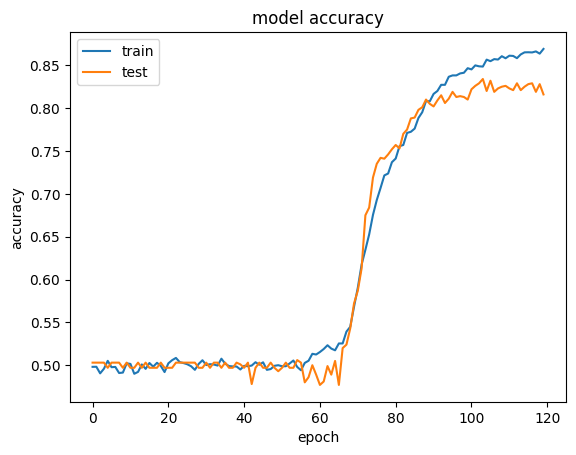

In [81]:
import matplotlib.pyplot as plt
%matplotlib inline
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Evaluating on Given Test Set

In [83]:
model.load_weights(filename)
pred_results = model.predict(([inputs_test, queries_test]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [84]:
test_data[0][0]

['Mary',
 'got',
 'the',
 'milk',
 'there',
 '.',
 'John',
 'moved',
 'to',
 'the',
 'bedroom',
 '.']

In [85]:
story =' '.join(word for word in test_data[0][0])
print(story)

Mary got the milk there . John moved to the bedroom .


In [86]:
query = ' '.join(word for word in test_data[0][1])
print(query)

Is John in the kitchen ?


In [87]:
print("True Test Answer from Data is:",test_data[0][2]) #actual answer

True Test Answer from Data is: no


In [88]:
pred_results[0]

array([4.0772083e-08, 4.1548020e-08, 3.9526327e-08, 4.4417170e-08,
       3.9528818e-08, 5.0617366e-08, 3.7943067e-08, 3.7685506e-08,
       3.9081485e-08, 4.1538829e-08, 4.6277641e-08, 4.6414211e-08,
       5.1075506e-08, 4.0042551e-08, 3.5649446e-08, 5.0753194e-08,
       5.4537121e-08, 4.8656155e-08, 4.2315552e-08, 4.7638942e-08,
       3.8355342e-08, 4.6162327e-08, 4.0566366e-08, 4.3633065e-08,
       4.4151022e-08, 4.9473023e-08, 4.3136161e-08, 5.3494521e-08,
       4.6992959e-08, 6.9626449e-03, 3.8652409e-08, 3.9312422e-08,
       3.4435189e-08, 9.9303591e-01, 4.0952745e-08, 4.9828913e-08,
       4.6130292e-08, 4.3477218e-08], dtype=float32)

In [89]:
#Generate prediction from model
val_max = np.argmax(pred_results[0])

for key, val in tokenizer.word_index.items():
    if val == val_max:
        k = key

print("Predicted answer is: ", k)
print("Probability of certainty was: ", pred_results[0][val_max])

Predicted answer is:  no
Probability of certainty was:  0.9930359


## Writing Your Own Stories and Questions

Remember you can only use words from the existing vocab

In [91]:
vocab

{'.',
 '?',
 'Daniel',
 'Is',
 'John',
 'Mary',
 'Sandra',
 'apple',
 'back',
 'bathroom',
 'bedroom',
 'discarded',
 'down',
 'dropped',
 'football',
 'garden',
 'got',
 'grabbed',
 'hallway',
 'in',
 'journeyed',
 'kitchen',
 'left',
 'milk',
 'moved',
 'no',
 'office',
 'picked',
 'put',
 'the',
 'there',
 'to',
 'took',
 'travelled',
 'up',
 'went',
 'yes'}

In [92]:
# Note the whitespace of the periods
my_story = "John left the kitchen . Sandra dropped the football in the garden ."
my_story.split()

['John',
 'left',
 'the',
 'kitchen',
 '.',
 'Sandra',
 'dropped',
 'the',
 'football',
 'in',
 'the',
 'garden',
 '.']

In [93]:
my_question = "Is the football in the garden ?"

In [94]:
my_question.split()

['Is', 'the', 'football', 'in', 'the', 'garden', '?']

In [95]:
mydata = [(my_story.split(),my_question.split(),'yes')]

In [96]:
my_story,my_ques,my_ans = vectorize_stories(mydata)

In [97]:
pred_results = model.predict(([ my_story, my_ques]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [98]:
#Generate prediction from model
val_max = np.argmax(pred_results[0])

for key, val in tokenizer.word_index.items():
    if val == val_max:
        k = key

print("Predicted answer is: ", k)
print("Probability of certainty was: ", pred_results[0][val_max])

Predicted answer is:  yes
Probability of certainty was:  0.78516877


# Great Job!